In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("kidney_disease.csv")

In [3]:
df

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [5]:
df.shape

(400, 26)

In [6]:
df[df.duplicated] #non of the rows is duplicated

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification


In [7]:
#id column has no mean it just a no. of non pattern so we generall drop id column

In [8]:
df.drop("id",axis = 1, inplace = True)

In [9]:
df

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [10]:
#since columns name does not justify or fairly tell about data so we are changing the column's name of the data 

In [11]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [12]:
df

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47,6700,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54,7800,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49,6600,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51,7200,5.9,no,no,no,good,no,no,notckd


In [13]:
#we can not directly convert the column which having nan values with integer into int by using astype so we have to use another pandas function 

In [14]:
df["packed_cell_volume"] = pd.to_numeric(df["packed_cell_volume"],errors = "coerce")

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [16]:
#Same for white_blood_cell_count and red_blood_cell_count

In [17]:
df["white_blood_cell_count"] = pd.to_numeric(df["white_blood_cell_count"],errors = "coerce")
df["red_blood_cell_count"] = pd.to_numeric(df["red_blood_cell_count"],errors = "coerce")

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [19]:
#now extracting numerical and catgorical data seprate

In [20]:
categorical = [feature for feature in df.columns if df[feature].dtype == "O"]

In [21]:
categorical

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'aanemia',
 'class']

In [22]:
numerical = [feature for feature in df.columns if df[feature].dtype != "O"]

In [23]:
numerical

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [24]:
#unique values for multiple columns in a single run

In [25]:
for col in categorical:
    print(f"{col} has unique values are {df[col].unique()} \ n")

red_blood_cells has unique values are [nan 'normal' 'abnormal'] \ n
pus_cell has unique values are ['normal' 'abnormal' nan] \ n
pus_cell_clumps has unique values are ['notpresent' 'present' nan] \ n
bacteria has unique values are ['notpresent' 'present' nan] \ n
hypertension has unique values are ['yes' 'no' nan] \ n
diabetes_mellitus has unique values are ['yes' 'no' ' yes' '\tno' '\tyes' nan] \ n
coronary_artery_disease has unique values are ['no' 'yes' '\tno' nan] \ n
appetite has unique values are ['good' 'poor' nan] \ n
peda_edema has unique values are ['no' 'yes' nan] \ n
aanemia has unique values are ['no' 'yes' nan] \ n
class has unique values are ['ckd' 'ckd\t' 'notckd'] \ n


In [26]:
#in diabetes_mellitus we see thier are some mistake by user on entering the data so we have to fix it

In [27]:
df["diabetes_mellitus"].unique()

array(['yes', 'no', ' yes', '\tno', '\tyes', nan], dtype=object)

In [28]:
df["diabetes_mellitus"] = df["diabetes_mellitus"].replace(to_replace = {" yes":"yes","\tyes":"yes","\tno":"no"})

In [29]:
df["diabetes_mellitus"].unique()

array(['yes', 'no', nan], dtype=object)

In [30]:
#SAme thing in the coronary_artery_disease column 

In [31]:
df["coronary_artery_disease"].unique()

array(['no', 'yes', '\tno', nan], dtype=object)

In [32]:
df["coronary_artery_disease"] = df["coronary_artery_disease"].replace(to_replace = {"\tno":"no"})

In [33]:
df["coronary_artery_disease"].unique()

array(['no', 'yes', nan], dtype=object)

In [34]:
#SAme thing in the class column

In [35]:

df["class"] = df["class"].replace(to_replace = {"ckd\t":"ckd"})

In [36]:
df["class"].unique()

array(['ckd', 'notckd'], dtype=object)

In [37]:
#ckd means chronic disease and notckd means no chronic disease so we map havind disease with 1 and not having with 0

In [38]:
df["class"] = df["class"].map({"ckd":"1","notckd":"0"})

In [39]:
df["class"].value_counts()

class
1    250
0    150
Name: count, dtype: int64

In [40]:
#now we see the well structured unique values

for col in categorical:
    print(f"{col} has unique values are {df[col].unique()} \n")

red_blood_cells has unique values are [nan 'normal' 'abnormal'] 

pus_cell has unique values are ['normal' 'abnormal' nan] 

pus_cell_clumps has unique values are ['notpresent' 'present' nan] 

bacteria has unique values are ['notpresent' 'present' nan] 

hypertension has unique values are ['yes' 'no' nan] 

diabetes_mellitus has unique values are ['yes' 'no' nan] 

coronary_artery_disease has unique values are ['no' 'yes' nan] 

appetite has unique values are ['good' 'poor' nan] 

peda_edema has unique values are ['no' 'yes' nan] 

aanemia has unique values are ['no' 'yes' nan] 

class has unique values are ['1' '0'] 



In [41]:
#now we are doing analysis  (EDA)

#Univariate(analysis each column one by one)

<Axes: xlabel='age', ylabel='Count'>

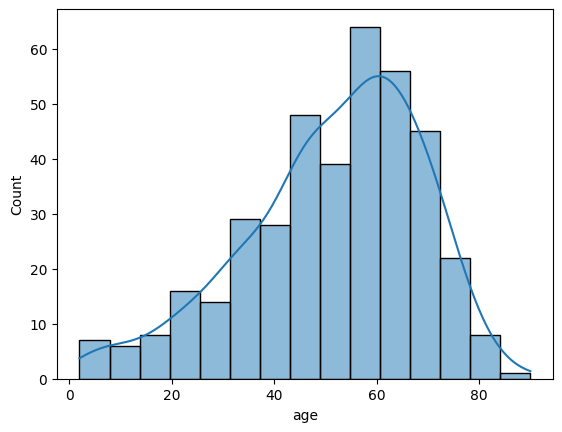

In [42]:
sns.histplot(x = df["age"].dropna(), data =  df, kde = True)

In [43]:
#insights -> Distribution of age id right screewed data

<Axes: xlabel='hypertension', ylabel='count'>

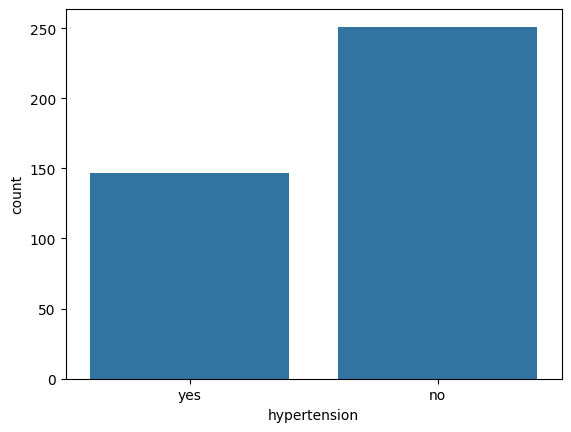

In [44]:
sns.countplot(x = df["hypertension"] , data = df)

<Axes: xlabel='class', ylabel='blood_urea'>

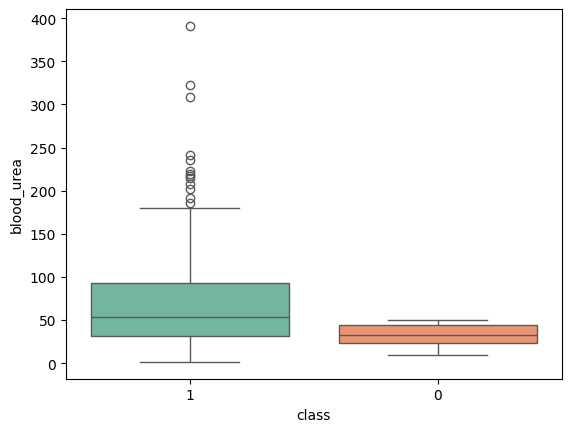

In [45]:
sns.boxplot(x = "class", y = "blood_urea",  data = df, palette = "Set2")

In [46]:
#insights -> people having ckd have higher blood urea

<Axes: xlabel='class', ylabel='serum_creatinine'>

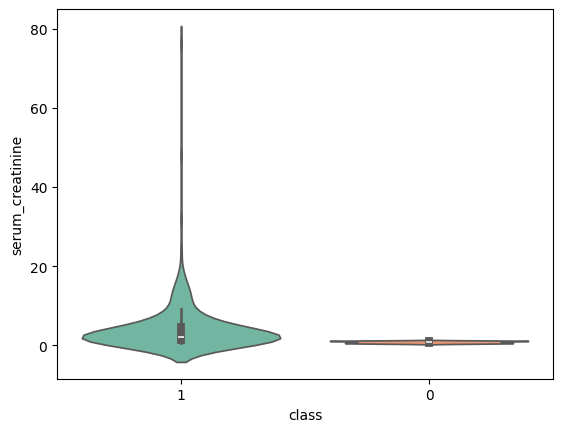

In [47]:
sns.violinplot(x = "class" , y = "serum_creatinine", data = df, palette = "Set2")

<Axes: xlabel='aanemia', ylabel='count'>

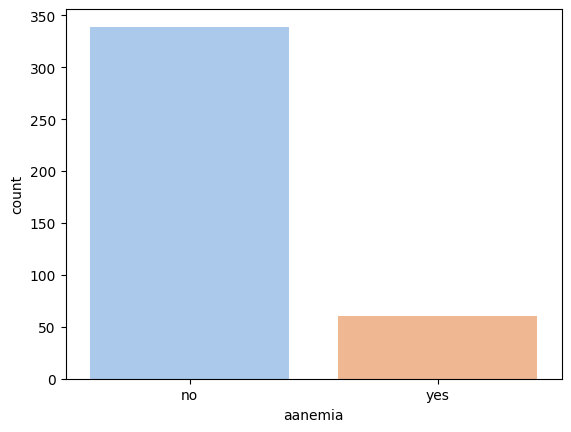

In [48]:
sns.countplot(x = df["aanemia"], data =df ,palette ="pastel" )

<Axes: ylabel='count'>

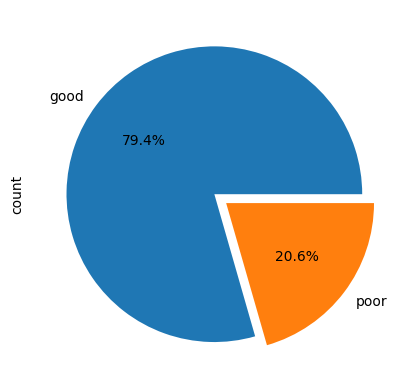

In [49]:
df["appetite"].value_counts().plot.pie(autopct = "%1.1f%%", explode = (0,0.1))

<Axes: xlabel='white_blood_cell_count', ylabel='Count'>

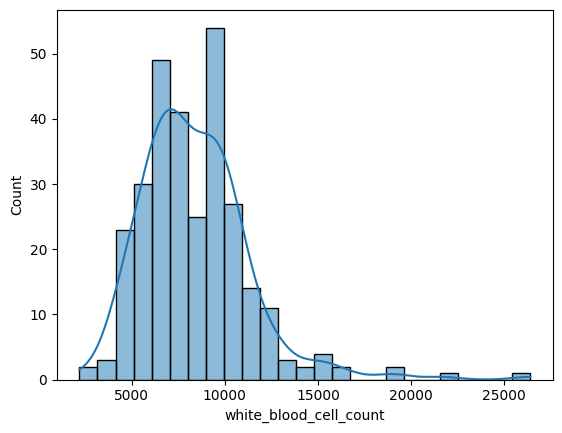

In [50]:
sns.histplot(df["white_blood_cell_count"].dropna(), kde = True)

<Axes: ylabel='count'>

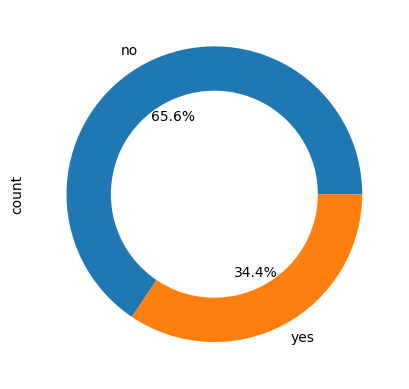

In [51]:
df["diabetes_mellitus"].value_counts().plot.pie(autopct = "%1.1f%%", wedgeprops = dict(width = 0.3))

In [52]:
#Bivariate analysis 

<Axes: xlabel='age', ylabel='blood_pressure'>

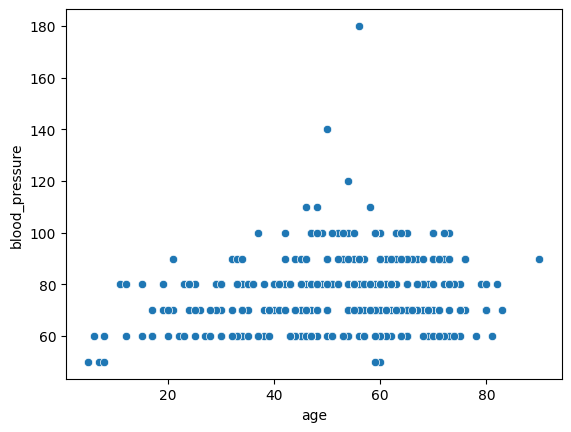

In [53]:
sns.scatterplot(x = "age", y = "blood_pressure", data = df)

<Axes: xlabel='age', ylabel='blood_pressure'>

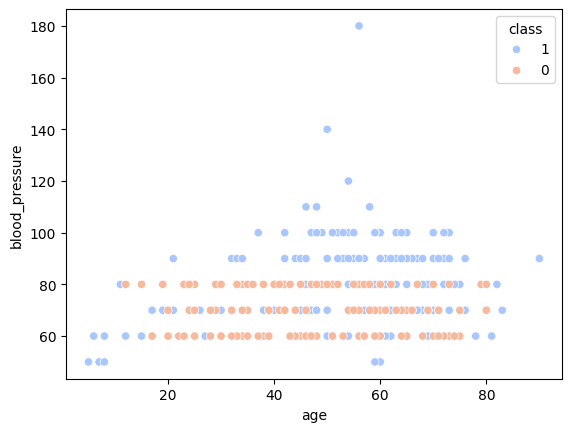

In [54]:
sns.scatterplot(x = "age", y = "blood_pressure", data = df,hue = "class", palette = "coolwarm")

In [55]:
#insights -> As the age increases the blood pressure also increases

<Axes: xlabel='diabetes_mellitus', ylabel='albumin'>

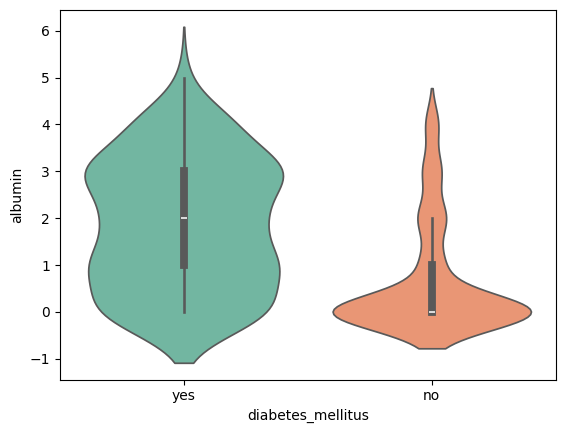

In [56]:
sns.violinplot(x = "diabetes_mellitus" ,y= "albumin", data = df, palette = "Set2")

In [57]:
diabetes_hypertension = pd.crosstab(df['diabetes_mellitus'], df['hypertension'])

In [58]:
diabetes_hypertension

hypertension,no,yes
diabetes_mellitus,,
no,220,41
yes,31,106


<Axes: xlabel='diabetes_mellitus'>

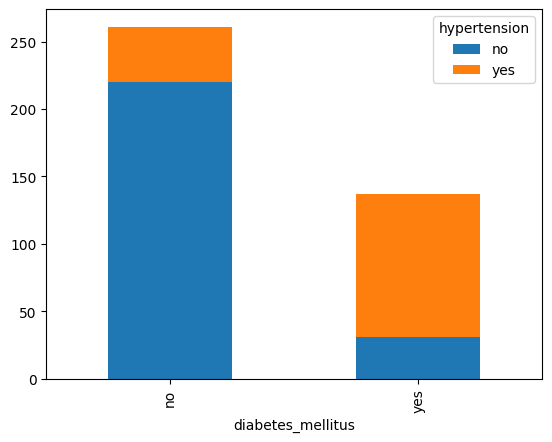

In [59]:
#Stacked Bar chart

diabetes_hypertension.plot(kind = "bar", stacked = True)

In [60]:
#multivariat analysis

In [61]:
#here we are making pairplots for some particular columns

cols = ['age', 'blood_pressure', 'blood_glucose_random', 'serum_creatinine', 'class']

<Figure size 2000x1500 with 0 Axes>

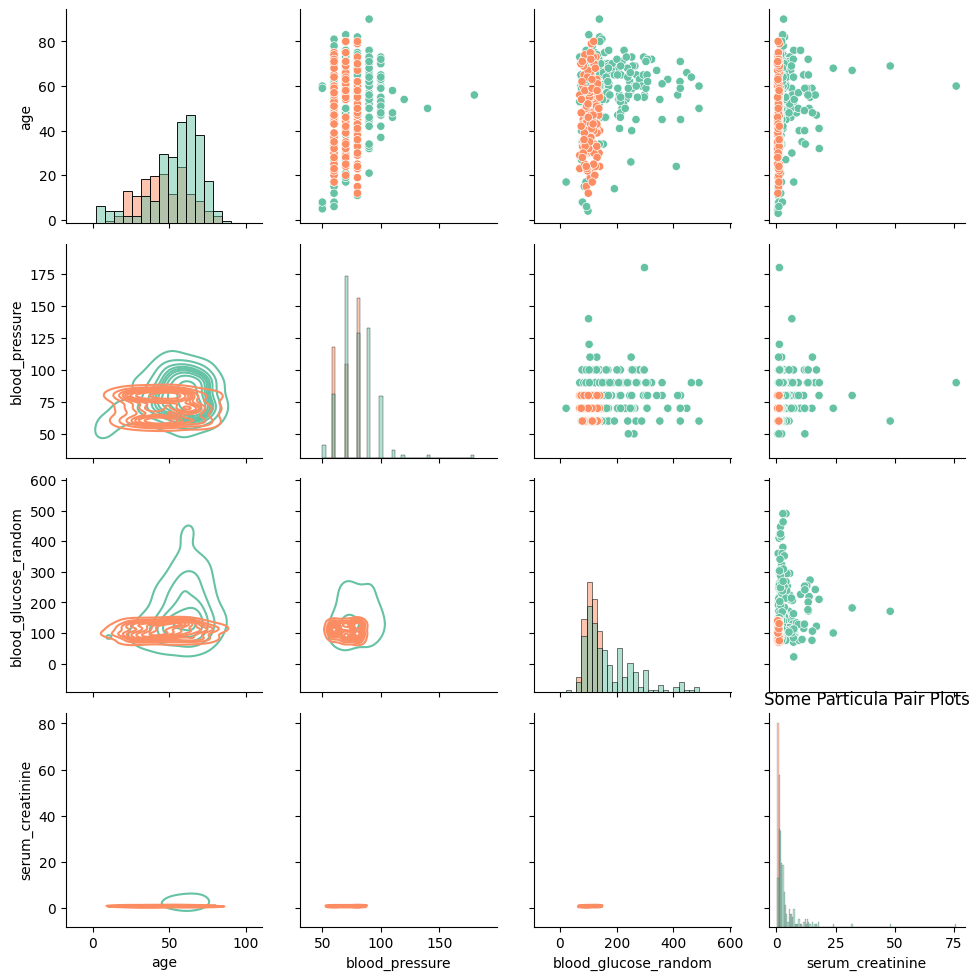

In [62]:
plt.figure(figsize = (20,15))

g = sns.PairGrid(df[cols], hue = "class", palette = "Set2")
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.histplot)
plt.title("Some Particula Pair Plots")
plt.show()

In [63]:
#Finding the corelation between the plots

<Axes: >

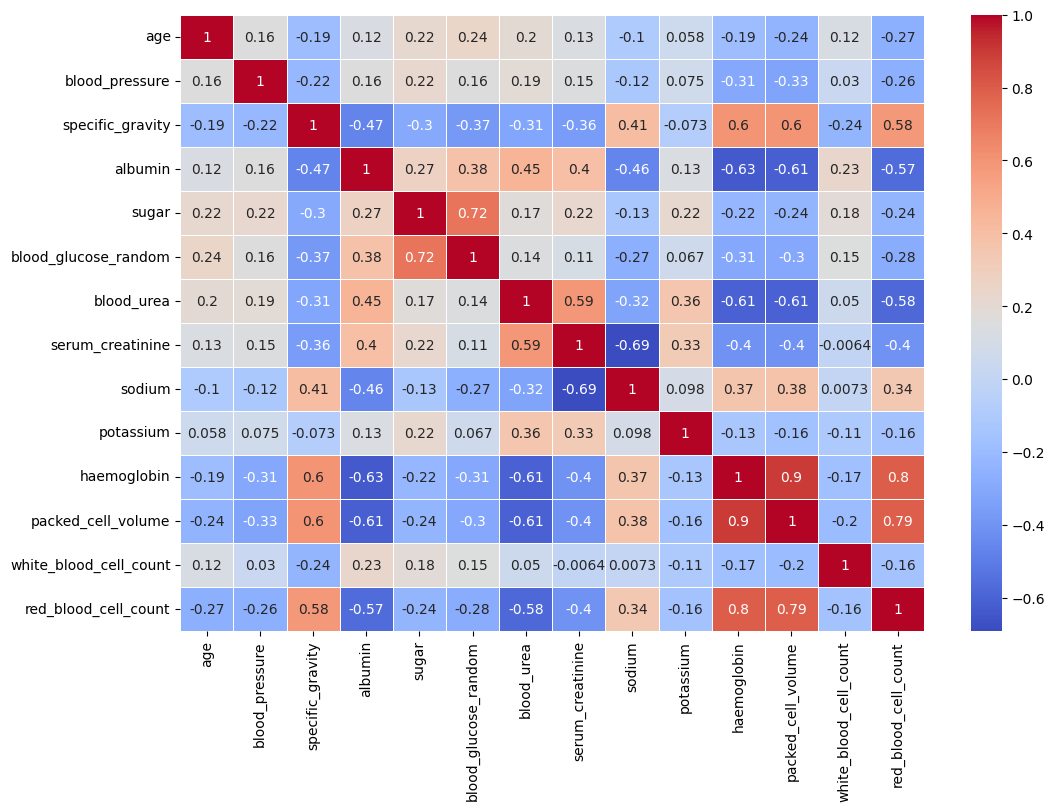

In [64]:
plt.figure(figsize = (12,8))
a = df.corr(numeric_only = True)
sns.heatmap(a,annot =True, cmap = "coolwarm", linewidth = 0.5)

<Axes: xlabel='diabetes_mellitus', ylabel='age'>

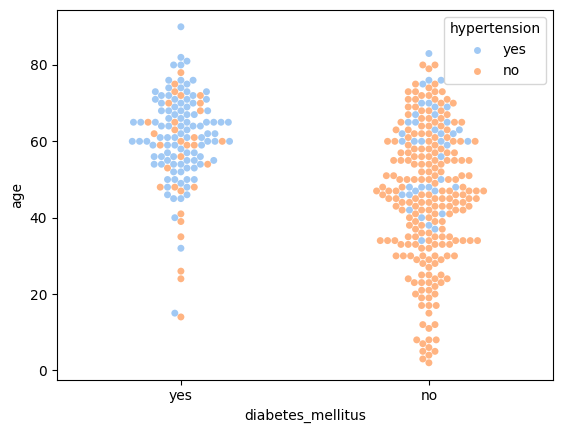

In [65]:
sns.swarmplot(x = "diabetes_mellitus",y = "age" ,data = df, hue = "hypertension",palette = "pastel")

In [66]:
#Plotly

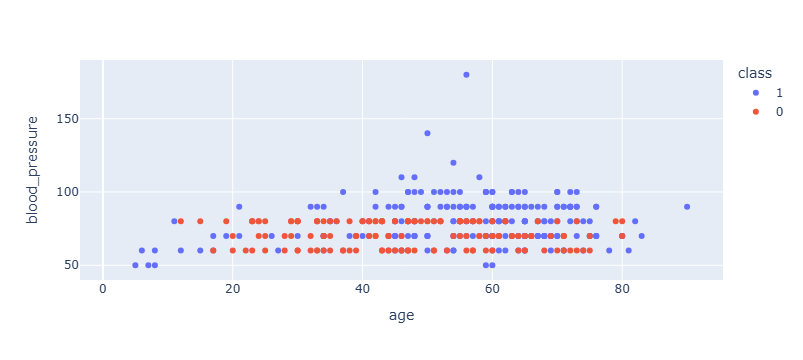

In [67]:
px.scatter(df, x = "age",y = "blood_pressure",color ="class")

In [70]:
#3-D plot

fig = px.scatter_3d(df, x = "age",y = "blood_pressure",z = "serum_creatinine",color ="class")

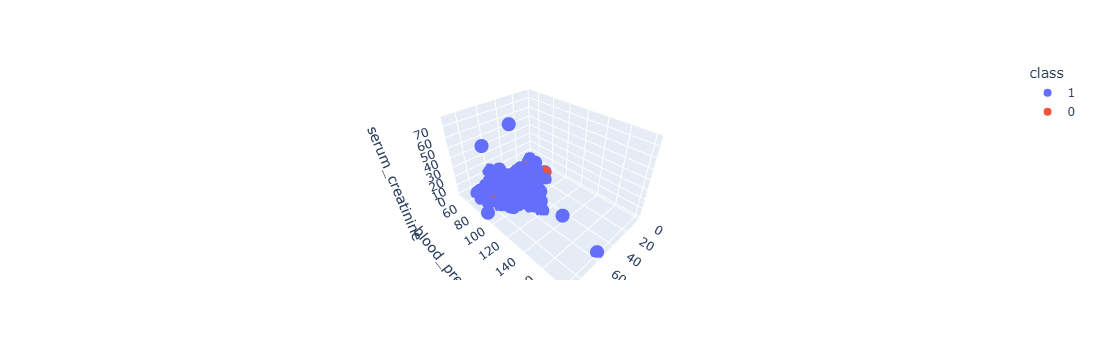

In [71]:
fig.show()

In [72]:
#Making interactive heat map

In [73]:
import plotly.graph_objects as go

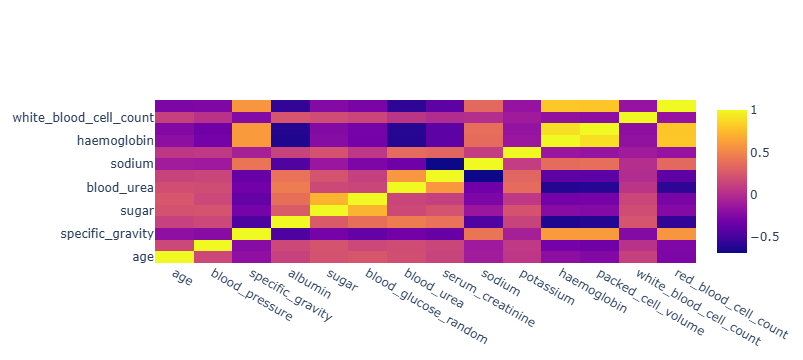

In [75]:
data_corr = df.corr(numeric_only = True)
fig = go.Figure(data = go.Heatmap(z = data_corr.values,
                           x = data_corr.columns,
                           y = data_corr.index))
fig.show()

In [76]:
categorical

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'aanemia',
 'class']

In [77]:
numerical

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [78]:
#We are doing the null values treatment

median_values = df[numerical].median()

In [79]:
median_values

age                         55.00
blood_pressure              80.00
specific_gravity             1.02
albumin                      0.00
sugar                        0.00
blood_glucose_random       121.00
blood_urea                  42.00
serum_creatinine             1.30
sodium                     138.00
potassium                    4.40
haemoglobin                 12.65
packed_cell_volume          40.00
white_blood_cell_count    8000.00
red_blood_cell_count         4.80
dtype: float64

In [91]:
df[numerical] = df[numerical].fillna(median_values)

In [92]:
df[numerical].isnull().sum()

age                       0
blood_pressure            0
specific_gravity          0
albumin                   0
sugar                     0
blood_glucose_random      0
blood_urea                0
serum_creatinine          0
sodium                    0
potassium                 0
haemoglobin               0
packed_cell_volume        0
white_blood_cell_count    0
red_blood_cell_count      0
dtype: int64

In [108]:
mode_values = df[categorical].mode().iloc[0]

In [109]:
mode_values

red_blood_cells                normal
pus_cell                       normal
pus_cell_clumps            notpresent
bacteria                   notpresent
hypertension                       no
diabetes_mellitus                  no
coronary_artery_disease            no
appetite                         good
peda_edema                         no
aanemia                            no
class                               1
Name: 0, dtype: object

In [110]:
df[categorical] = df[categorical].fillna(mode_values)

In [111]:
df[categorical].isnull().sum()

red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
class                      0
dtype: int64

In [112]:
#Converting the categorical columns into int by using label encoding

In [114]:
from sklearn.preprocessing import LabelEncoder
scaler = LabelEncoder()

In [115]:
for col in categorical:
    df[col] = scaler.fit_transform(df[col])

In [116]:
df

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,55.0,80.0,1.02,0.0,0.0,1,1,0,0,121.0,...,40.0,8000.0,4.8,1,1,0,0,0,0,1
1,55.0,80.0,1.02,0.0,0.0,1,1,0,0,121.0,...,40.0,8000.0,4.8,0,0,0,0,0,0,1
2,55.0,80.0,1.02,0.0,0.0,1,1,0,0,121.0,...,40.0,8000.0,4.8,0,1,0,1,0,1,1
3,55.0,80.0,1.02,0.0,0.0,1,0,1,0,121.0,...,40.0,8000.0,4.8,1,0,0,1,1,1,1
4,55.0,80.0,1.02,0.0,0.0,1,1,0,0,121.0,...,40.0,8000.0,4.8,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.02,0.0,0.0,1,1,0,0,121.0,...,40.0,8000.0,4.8,0,0,0,0,0,0,0
396,55.0,80.0,1.02,0.0,0.0,1,1,0,0,121.0,...,40.0,8000.0,4.8,0,0,0,0,0,0,0
397,55.0,80.0,1.02,0.0,0.0,1,1,0,0,121.0,...,40.0,8000.0,4.8,0,0,0,0,0,0,0
398,55.0,80.0,1.02,0.0,0.0,1,1,0,0,121.0,...,40.0,8000.0,4.8,0,0,0,0,0,0,0
